In [ ]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive')

['photo 4.jpg',
 'Screenshot_20251007-132705.png',
 'Bonafied.pdf',
 'Colab Notebooks',
 'courses certificate.pdf',
 'shared_image.png',
 'gaytri idcard.pdf',
 '3 person id card.pdf',
 'id card manish.pdf',
 'archive (1).zip']

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/archive (1).zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [ ]:
import os
import shutil

# path
base_path = "/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

train_path = os.path.join(base_path, "train")
valid_path = os.path.join(base_path, "valid")

mini_base = "/content/mini_plant_dataset"

classes = [
    "Tomato___healthy",
    "Tomato___Early_blight",
    "Tomato___Late_blight"
]

# folders create
for split in ["train", "valid"]:
    for cls in classes:
        os.makedirs(os.path.join(mini_base, split, cls), exist_ok=True)

# copy images automatically
for cls in classes:
    train_imgs = os.listdir(os.path.join(train_path, cls))[:50]
    valid_imgs = os.listdir(os.path.join(valid_path, cls))[:10]

    for img in train_imgs:
        shutil.copy(
            os.path.join(train_path, cls, img),
            os.path.join(mini_base, "train", cls, img)
        )

    for img in valid_imgs:
        shutil.copy(
            os.path.join(valid_path, cls, img),
            os.path.join(mini_base, "valid", cls, img)
        )

print("Mini dataset ready!")

Mini dataset ready!


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# image settings
img_size = (128, 128)
batch_size = 16

# preprocessing
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# load train data
train_data = train_datagen.flow_from_directory(
    "/content/mini_plant_dataset/train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# load validation data
valid_data = valid_datagen.flow_from_directory(
    "/content/mini_plant_dataset/valid",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

print("Data Loaded Successfully!")

Found 150 images belonging to 3 classes.
Found 30 images belonging to 3 classes.
Data Loaded Successfully!


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(3, activation='softmax')   # 3 classes
])

# compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,707 (28.20 MB)

 Trainable params: 7,392,707 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=5
)

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 370ms/step - accuracy: 0.4000 - loss: 1.9386 - val_accuracy: 0.5333 - val_loss: 1.0349
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6867 - loss: 0.9535 - val_accuracy: 0.8667 - val_loss: 0.7974
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7200 - loss: 0.6932 - val_accuracy: 0.8000 - val_loss: 0.6164
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.7933 - loss: 0.4850 - val_accuracy: 0.8333 - val_loss: 0.5555
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.9000 - loss: 0.3030 - val_accuracy: 0.7333 - val_loss: 0.5248


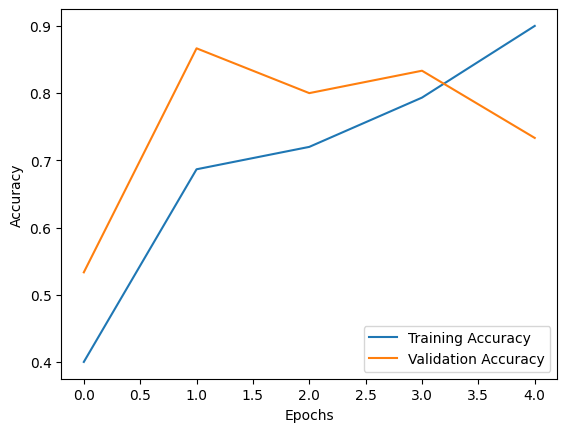

In [ ]:
import matplotlib.pyplot as plt

# accuracy graph
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
model.save("plant_disease_model.h5")
print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
import os

print(os.listdir("/content/dataset/test/test")[:10])

['TomatoYellowCurlVirus6.JPG', 'PotatoHealthy1.JPG', 'TomatoEarlyBlight2.JPG', 'PotatoEarlyBlight1.JPG', 'AppleScab2.JPG', 'TomatoEarlyBlight6.JPG', 'TomatoHealthy3.JPG', 'PotatoEarlyBlight5.JPG', 'TomatoEarlyBlight4.JPG', 'CornCommonRust2.JPG']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    "/content/mini_plant_dataset/valid",
    target_size=(128,128),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc*100, "%")

Found 30 images belonging to 3 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7333 - loss: 0.5248
Test Accuracy: 73.33333492279053 %


Dropdown(description='Select Image:', options=('TomatoYellowCurlVirus6.JPG', 'PotatoHealthy1.JPG', 'TomatoEarl…

Button(description='Predict', style=ButtonStyle())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step


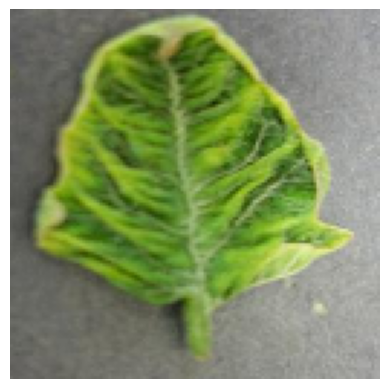

Predicted Disease: Tomato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


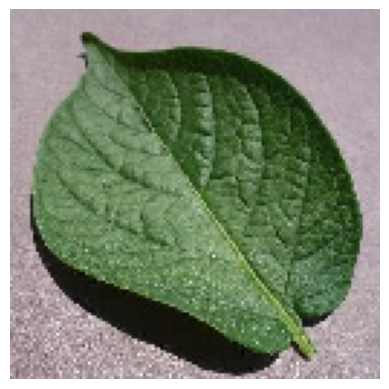

Predicted Disease: Tomato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


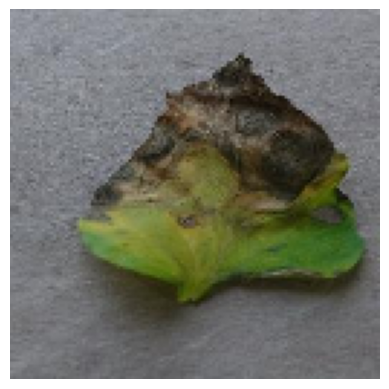

Predicted Disease: Tomato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


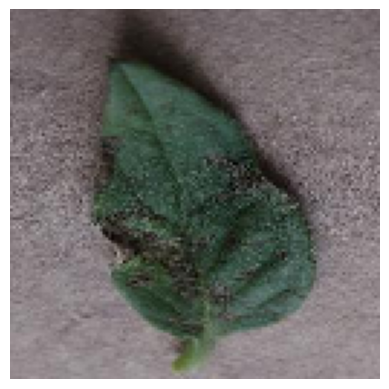

Predicted Disease: Tomato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


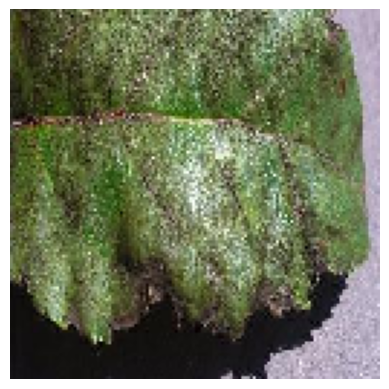

Predicted Disease: Tomato___Late_blight


In [ ]:
import ipywidgets as widgets
from IPython.display import display
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os

# test folder images
test_folder = "/content/dataset/test/test"
images = os.listdir(test_folder)

# dropdown
dropdown = widgets.Dropdown(
    options=images,
    description='Select Image:'
)

button = widgets.Button(description="Predict")

def predict_image(b):
    img_path = os.path.join(test_folder, dropdown.value)

    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    class_names = ['Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']
    predicted_class = class_names[np.argmax(prediction)]

    plt.imshow(img)
    plt.axis('off')
    plt.show()

    print("Predicted Disease:", predicted_class)

button.on_click(predict_image)

display(dropdown, button)